**STAT 426: Homework-2**
- **UID: 206547205**
- **Name: Hochan Son**
- **Email: hochanson@g.ucla.edu**

# Problem 1: Image Classification with CIFAR-10
Consider the CIFAR-10 dataset, which consists of 60,000 color images of size 32 × 32 × 3, labeled into 10 object classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship,
truck. The dataset is divided into 50,000 training images and 10,000 test images, evenly distributed across classes. For all experiments, create a validation set by holding out 5,000 images from the training set. The test set should be used only for final evaluation.


### Part (a): Baseline CNN [70 Points]
Implement a Baseline convolutional neural network (CNN) architecture from scratch. Your model must follow the architecture specified below.
- Input: 32 × 32 × 3 image.
- Block 1: Conv2D (32 filters, 3 × 3, padding = 1) → ReLU → MaxPool (2 × 2).
- Block 2: Conv2D (64 filters, 3 × 3, padding = 1) → ReLU → MaxPool (2 × 2).
- Block 3: Conv2D (64 filters, 3 × 3, padding = 1) → ReLU.
- Flatten Layer.
- Fully Connected Layer: 64 hidden nodes (units) → ReLU.
- Output Layer: Fully connected (linear) layer with 10 units.

(Note: When using PyTorch’s CrossEntropyLoss, output raw logits rather than applying a Softmax activation explicitly.)

### Tasks:
1. Training Procedure: Train the model for 15 epochs using the Adam optimizer (learning rate = 0.001) and Cross-Entropy Loss. Use a batch size of 64.
2. Training Deliverables: Provide the following outputs from your training run:
- A model summary listing layer names, output shapes, and the number of parameters.
- A plot showing training and validation accuracy across epochs.
3. Performance Evaluation: Evaluate the trained model on the CIFAR-10 test set and report:
- Final test accuracy.
- Final test cross-entropy loss.
4. Error Analysis: Compute and visualize the confusion matrix for the test set. Based on this analysis:
- Identify which classes are most frequently confused.
- Provide a plausible explanation for these errors based on visual similarity.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score

# ==============================================================================
# PART 1: CONFIGURATION & EXPLANATION
# ==============================================================================
# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001  
EPOCHS = 15 


# The 10 classes in CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Device configuration (Use GPU if available, otherwise CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Version (PyTorch built with): {torch.version.cuda}")
print(f"Is CUDA available? {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Capability: {torch.cuda.get_device_capability(0)}")

Running on device: cuda:0
PyTorch Version: 2.11.0.dev20260212+cu130
CUDA Version (PyTorch built with): 13.0
Is CUDA available? True
GPU Name: NVIDIA GB10
GPU Capability: (12, 1)


In [2]:
class BASELINE_CNN(nn.Module):
    def __init__(self):
        super(BASELINE_CNN, self).__init__()

        self.shape = None
        self.shapes = []
        
        # Block 1: Conv2D (32 filters, 3x3, padding=1) -> ReLU -> MaxPool (2x2)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        

        
        # Block 2: Conv2D (64 filters, 3x3, padding=1) -> ReLU -> MaxPool (2x2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Block 3: Conv2D (64 filters, 3x3, padding=1) -> ReLU
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)
        
        
    def forward(self, x):
        # Block 1
        x = self.pool1(F.relu(self.conv1(x)))
        list(x.shape)
        # Block 2
        x = self.pool2(F.relu(self.conv2(x)))
        
        # Block 3
        x = F.relu(self.conv3(x))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully Connected Layer
        x = F.relu(self.fc1(x))
        
        # Output Layer
        x = self.fc2(x)
        return x

    def train_model(self, train_loader, val_loader, epochs,
                   criterion=None, optimizer=None, verbose=True):
        """
        Train the model using provided data loaders.

        Args:
            train_loader (DataLoader): Training data
            val_loader (DataLoader): Validation data
            epochs (int): Number of training epochs
            criterion: Loss function (default: Crossentropy loss)
            optimizer: Optimizer (default: SGD with self.lr)
            verbose (bool): Print progress every 5 epochs
        """
        # Detect device (GPU or CPU)
        device = next(self.parameters()).device
        
        # Setup loss and optimizer
        if criterion is None:
            criterion = nn.CrossEntropyLoss()
        if optimizer is None:
            optimizer = optim.Adam(self.parameters())

        # Reset history
        self.train_loss_history = []
        self.train_acc_history = []
        self.val_loss_history = []
        self.val_acc_history = []

        if verbose:
            print(f"\nTraining for {epochs} epochs...")
            print(f"Device: {device}")
            print(f"\nTraining for {epochs} epochs on {device}")

        for epoch in range(epochs):
            # Training phase
            self.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0
            for inputs, labels in train_loader:
                # Move data to same device as model
                # inputs = inputs.to(device)
                # labels = labels.to(device)
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                train_correct += (preds == labels).sum().item()
                train_total += labels.size(0)

            # avg_train_loss = train_loss / len(train_loader.dataset)
            avg_train_loss = train_loss / train_total
            train_acc = train_correct / train_total
            self.train_loss_history.append(avg_train_loss)
            self.train_acc_history.append(train_acc)

            # Validation phase
            self.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    # Move data to same device as model
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = self(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)
                    _, preds = torch.max(outputs,1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            avg_val_loss = val_loss / val_total
            val_acc = val_correct / val_total
            self.val_loss_history.append(avg_val_loss)
            self.val_acc_history.append(val_acc)

            # Print progress
            if verbose:
                print(f"Epoch {epoch+1:2d}/{epochs} | "
                      f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.4f} | "
                      f"Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.4f}")

    def evaluate(self, data_loader, criterion):
        """
        Evaluate model on provided data.

        Args:
            data_loader (DataLoader): Data to evaluate

        Returns:
            dict: Contains 'targets', 'predictions', 'accuracy', 'auc'
        """
        # Detect device (GPU or CPU)
        device = next(self.parameters()).device
        self.eval()
        all_targets = []
        all_preds = []
        total_loss = 0.0
        total = 0

        with torch.no_grad():
            for inputs, labels in data_loader:
                # Move data to same device as model
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self(inputs)
                # probs = torch.softmax(outputs)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                all_targets.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                total += labels.size(0)

        targets = np.array(all_targets)
        predictions = np.array(all_preds)
        accuracy = accuracy_score(targets, predictions)
        avg_loss = total_loss / total

        # accuracy = accuracy_score(targets, (predictions > 0.5).astype(int))
        # auc_score = roc_auc_score(targets, predictions)

        return {
            'targets': targets,
            'predictions': predictions,
            'accuracy': accuracy,
            # 'auc': auc_score,
            'loss': avg_loss
        }

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

def plot_training_curves(model, title='Training Curves'):
    """
    Plots loss and accuracy curves from model history attributes.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(model.train_loss_history, label='Train Loss')
    ax1.plot(model.val_loss_history, label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss'); ax1.legend(); ax1.grid(True)

    ax2.plot(model.train_acc_history, label='Train Acc')
    ax2.plot(model.val_acc_history, label='Val Acc')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy'); ax2.legend(); ax2.grid(True)

    plt.tight_layout(); plt.show()


def plot_confusion_matrix(targets, predictions, class_names, title='Confusion Matrix'):
    """
    Plots a confusion matrix heatmap.
    """
    cm = confusion_matrix(targets, predictions)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(title)
    plt.tight_layout(); plt.show()

def evaluate_model(model, loader):
    """
    Evaluates the model on the given data loader and returns the accuracy.
    """
    device = next(model.parameters()).device
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            
    accuracy = accuracy_score(all_targets, all_preds)
    return accuracy * 100  # Return percentage


def inspect_model_shapes(model):
    """
    Prints the output shapes of each layer in the model.
    """
    print("\n" + "="*70)
    print("MODEL ARCHITECTURE SUMMARY")    
    print("="*70)
    print(f"{'Layer':<30} {'Weight Shape':<25} {'Params':>10}")
    print("="*70)
    for name, param in model.named_parameters():
        print(f"{name:<30} {str(list(param.shape)):<25} {param.numel():>10,}")
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print("-"*70)
    print(f"{'Total parameters':<32} {total_params:>10,}")
    print(f"{'Trainable parameters':<32} {trainable_params:>10,}")
    print("="*70 + "\n")

Training: 45000 | Validation: 5000 | Test: 10000
BASELINE_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

Training for 15 epochs...
Device: cuda:0

Training for 15 epochs on cuda:0
Epoch  1/15 | Train Loss: 1.4750 Acc: 0.4626 | Val Loss: 1.2689 Acc: 0.5474
Epoch  2/15 | Train Loss: 1.0730 Acc: 0.6197 | Val Loss: 0.9864 Acc: 0.6442
Epoch  3/15 | Train Loss: 0.8921 Acc: 0.6865 | Val Loss: 0.9243 Acc: 0.6678
Epoch  4/15 | Train Loss: 0.7761 Acc: 0.7296 | Val Loss: 0.8783 Acc: 0.6954
Epoch  5/15 | Train Loss: 0.686

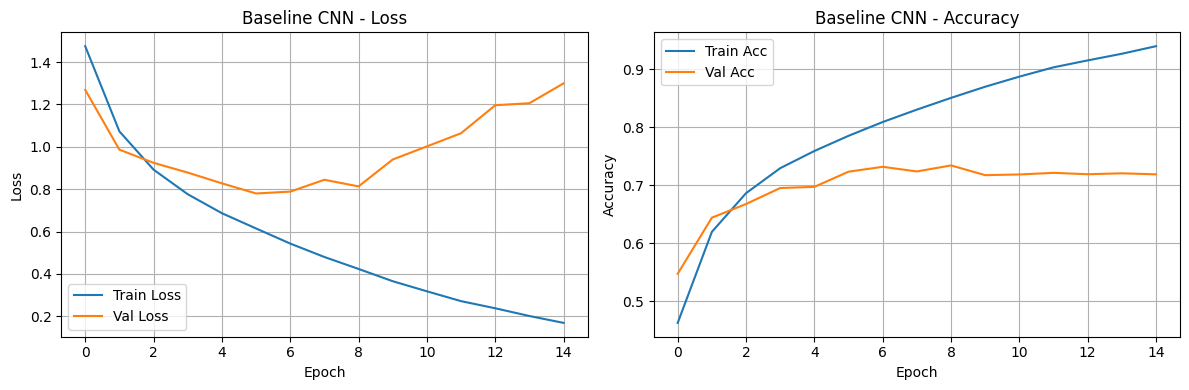


Final Test Accuracy: 0.7220
Final Test Cross-Entropy Loss: 1.3138


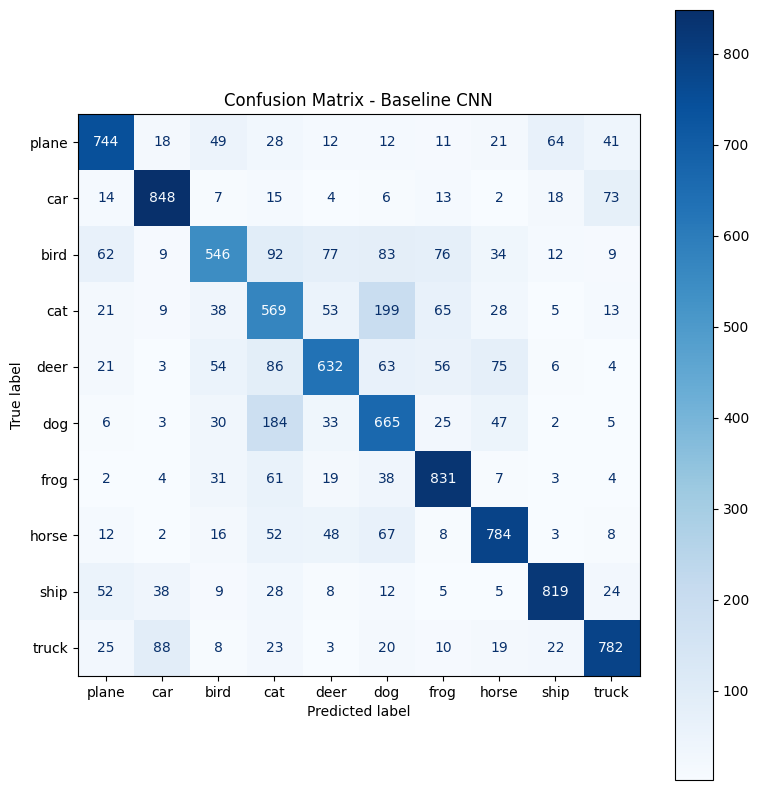


MODEL ARCHITECTURE SUMMARY
Layer                          Weight Shape                  Params
conv1.weight                   [32, 3, 3, 3]                    864
----------------------------------------------------------------------
conv1.bias                     [32]                              32
----------------------------------------------------------------------
conv2.weight                   [64, 32, 3, 3]                18,432
----------------------------------------------------------------------
conv2.bias                     [64]                              64
----------------------------------------------------------------------
conv3.weight                   [64, 64, 3, 3]                36,864
----------------------------------------------------------------------
conv3.bias                     [64]                              64
----------------------------------------------------------------------
fc1.weight                     [64, 4096]                   262,144
--

In [4]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
#from utils import plot_training_curves, evaluate_model, inspect_model_shapes, plot_confusion_matrix

def main():
    # 1. Data Preparation
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load full training set (50,000 images), hold out 5,000 for validation
    full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                  download=True, transform=transform)
    trainset, valset = random_split(full_trainset, [45000, 5000],
                                    generator=torch.Generator().manual_seed(42))

    trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    valloader = DataLoader(valset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Test set - only for final evaluation
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Training: {len(trainset)} | Validation: {len(valset)} | Test: {len(testset)}")

    # 2. Initialize Model on GPU
    model = BASELINE_CNN().to(device)
    print(model)

    # 3. Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 4. Train
    model.train_model(trainloader, valloader, epochs=EPOCHS,
                      criterion=criterion, optimizer=optimizer)

    # 5. Plot training and validation curves
    plot_training_curves(model, title='Baseline CNN')

    # 6. Evaluate on test set
    results = model.evaluate(testloader, criterion)
    print(f"\nFinal Test Accuracy: {results['accuracy']:.4f}")
    print(f"Final Test Cross-Entropy Loss: {results['loss']:.4f}")

    # 7. Confusion matrix
    plot_confusion_matrix(results['targets'], results['predictions'],
                          class_names=classes, title='Confusion Matrix - Baseline CNN')

    # 8. Inspect architecture shapes
    inspect_model_shapes(model)

if __name__=="__main__":
    main()

### Part (b): Enhanced CNN [30 Points]
The goal of this part is to replace dense layers with convolutional and pooling operations in
order to reduce the number of parameters and improve generalization.
Construct a new model, called EnhancedCNN, by modifying the Baseline architecture as
follows:

1. Batch Normalization: Add a BatchNorm2d layer after every convolutional layer,
following the pattern:
Conv → BatchNorm → ReLU.
2. Global Average Pooling & Fully Convolutional Output:
- Remove the Flatten layer and the fully connected layers entirely.
- Add a 1 × 1 Convolution layer after Block 3 with 10 filters (one per class).
- Apply Global Average Pooling to the output of this 1 × 1 conv layer.
- This results in a tensor of shape 1 × 1 × 10 per image, which should be reshaped
or squeezed into a vector of length 10 before computing the loss.
Tasks:
1. Train the EnhancedCNN for 20 epochs (or longer if necessary for convergence).
2. Compare its performance to the Baseline model using the same evaluation metrics;
specifically:
• Training and validation loss curves
• Final test accuracy and test cross-entropy loss
• Confusion matrix
.
3. Briefly discuss the impact of these changes on model performance and parameter count.
1Note: This makes the network ”Fully Convolutional,” meaning it has zero Dense layers.


In [5]:
class ENHANCED_CNN(nn.Module):
    def __init__(self):
        super(ENHANCED_CNN, self).__init__()
        
        # Block 1: Conv2D (32 filters, 3x3, padding=1) -> BatchNorm -> ReLU -> MaxPool (2x2)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Block 2: Conv2D (64 filters, 3x3, padding=1) -> BatchNorm -> ReLU -> MaxPool (2x2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Block 3: Conv2D (64 filters, 3x3, padding=1) -> BatchNorm -> ReLU
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=2)
        self.bn3 = nn.BatchNorm2d(64)

        # 1x1 Conv to map 64 channels -> 10 classes (fully convolutional output)
        self.conv1x1 = nn.Conv2d(64, 10, kernel_size=1)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        
    def forward(self, x):
        # Block 1
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        #x = F.relu(self.bn1(self.conv1(x)))
        # Block 2
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        #x = F.relu(self.bn2(self.conv2(x)))
        
        # Block 3
        x = F.relu(self.bn3(self.conv3(x)))

        # 1x1 Conv -> Global Average Pooling -> squeeze to (batch, 10)
        x = self.conv1x1(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        
        return x

    def train_model(self, train_loader, val_loader, epochs,
                   criterion=None, optimizer=None, verbose=True):
        """
        Train the model using provided data loaders.

        Args:
            train_loader (DataLoader): Training data
            val_loader (DataLoader): Validation data
            epochs (int): Number of training epochs
            criterion: Loss function (default: Crossentropy loss)
            optimizer: Optimizer (default: SGD with self.lr)
            verbose (bool): Print progress every 5 epochs
        """
        # Detect device (GPU or CPU)
        device = next(self.parameters()).device
        
        # Setup loss and optimizer
        if criterion is None:
            criterion = nn.CrossEntropyLoss()
        if optimizer is None:
            optimizer = optim.Adam(self.parameters())

        # Reset history
        self.train_loss_history = []
        self.train_acc_history = []
        self.val_loss_history = []
        self.val_acc_history = []

        if verbose:
            print(f"\nTraining for {epochs} epochs...")
            print(f"Device: {device}")
            print(f"\nTraining for {epochs} epochs on {device}")

        for epoch in range(epochs):
            # Training phase
            self.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0
            for inputs, labels in train_loader:
                # Move data to same device as model
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                train_correct += (preds == labels).sum().item()
                train_total += labels.size(0)

            avg_train_loss = train_loss / train_total
            train_acc = train_correct / train_total
            self.train_loss_history.append(avg_train_loss)
            self.train_acc_history.append(train_acc)

            # Validation phase
            self.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    # Move data to same device as model
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = self(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)
                    _, preds = torch.max(outputs,1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            avg_val_loss = val_loss / val_total
            val_acc = val_correct / val_total
            self.val_loss_history.append(avg_val_loss)
            self.val_acc_history.append(val_acc)

            # Print progress
            if verbose:
                print(f"Epoch {epoch+1:2d}/{epochs} | "
                      f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.4f} | "
                      f"Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.4f}")

    def evaluate(self, data_loader, criterion):
        """
        Evaluate model on provided data.

        Args:
            data_loader (DataLoader): Data to evaluate

        Returns:
            dict: Contains 'targets', 'predictions', 'accuracy', 'auc'
        """
        # Detect device (GPU or CPU)
        device = next(self.parameters()).device
        self.eval()
        all_targets = []
        all_preds = []
        total_loss = 0.0
        total = 0

        with torch.no_grad():
            for inputs, labels in data_loader:
                # Move data to same device as model
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                all_targets.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                total += labels.size(0)

        targets = np.array(all_targets)
        predictions = np.array(all_preds)
        accuracy = accuracy_score(targets, predictions)
        avg_loss = total_loss / total

        return {
            'targets': targets,
            'predictions': predictions,
            'accuracy': accuracy,
            'loss': avg_loss
        }

Training: 45000 | Validation: 5000 | Test: 10000
ENHANCED_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1x1): Conv2d(64, 10, kernel_size=(1, 1), stride=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=1)
)

Training for 15 epochs...
Device: cuda:0

Training for 15 epochs on cuda:0
Epoch  1/15 | Train Loss: 1.3822 Acc: 0.5075 | Val Loss: 1.1988 Acc: 0.5712
Epoch  2/

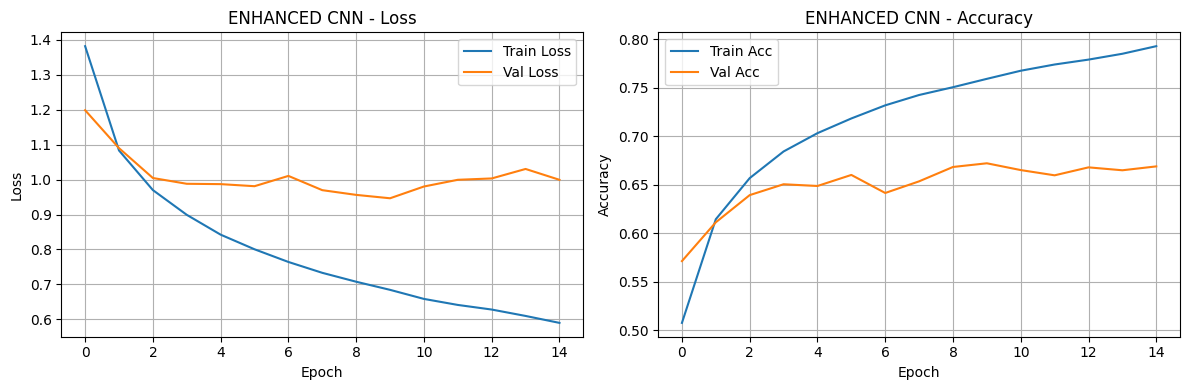


Final Test Accuracy: 0.6647
Final Test Cross-Entropy Loss: 1.0158


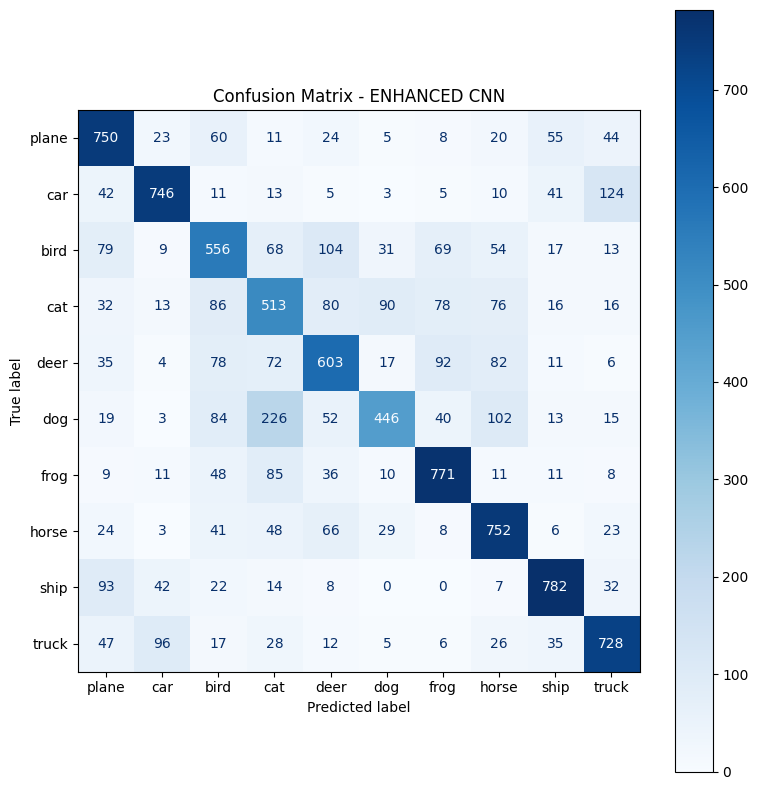


MODEL ARCHITECTURE SUMMARY
Layer                          Weight Shape                  Params
conv1.weight                   [32, 3, 3, 3]                    864
----------------------------------------------------------------------
conv1.bias                     [32]                              32
----------------------------------------------------------------------
bn1.weight                     [32]                              32
----------------------------------------------------------------------
bn1.bias                       [32]                              32
----------------------------------------------------------------------
conv2.weight                   [64, 32, 3, 3]                18,432
----------------------------------------------------------------------
conv2.bias                     [64]                              64
----------------------------------------------------------------------
bn2.weight                     [64]                              64
--

In [6]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
#from utils import plot_training_curves, evaluate_model, inspect_model_shapes, plot_confusion_matrix

def main():
    # 1. Data Preparation
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load full training set (50,000 images), hold out 5,000 for validation
    full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                  download=True, transform=transform)
    trainset, valset = random_split(full_trainset, [45000, 5000],
                                    generator=torch.Generator().manual_seed(42))

    trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    valloader = DataLoader(valset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Test set - only for final evaluation
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Training: {len(trainset)} | Validation: {len(valset)} | Test: {len(testset)}")

    # 2. Initialize Model on GPU
    model = ENHANCED_CNN().to(device)
    print(model)

    # 3. Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 4. Train
    model.train_model(trainloader, valloader, epochs=EPOCHS,
                      criterion=criterion, optimizer=optimizer)

    # 5. Plot training and validation curves
    plot_training_curves(model, title='ENHANCED CNN')

    # 6. Evaluate on test set
    results = model.evaluate(testloader, criterion)
    print(f"\nFinal Test Accuracy: {results['accuracy']:.4f}")
    print(f"Final Test Cross-Entropy Loss: {results['loss']:.4f}")

    # 7. Confusion matrix
    plot_confusion_matrix(results['targets'], results['predictions'],
                          class_names=classes, title='Confusion Matrix - ENHANCED CNN')

    # 8. Inspect architecture shapes
    inspect_model_shapes(model)

if __name__=="__main__":
    main()

In [7]:
class ENHANCED_CNN2(nn.Module):
    def __init__(self):
        super(ENHANCED_CNN2, self).__init__()
        
        # Block 1: Conv2D (32 filters, 3x3, padding=1) -> BatchNorm -> ReLU -> MaxPool (2x2)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=2)
        self.bn1 = nn.BatchNorm2d(32)
        #self.pool1 = nn.MaxPool2d(2, 2)
        
        # Block 2: Conv2D (64 filters, 3x3, padding=1) -> BatchNorm -> ReLU -> MaxPool (2x2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2)
        self.bn2 = nn.BatchNorm2d(64)
        #self.pool2 = nn.MaxPool2d(2, 2)

        # Block 3: Conv2D (64 filters, 3x3, padding=1) -> BatchNorm -> ReLU
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1, stride=2)
        self.bn3 = nn.BatchNorm2d(64)

        # 1x1 Conv to map 64 channels -> 10 classes (fully convolutional output)
        self.conv1x1 = nn.Conv2d(64, 10, kernel_size=1)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        
    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        # Block 2
        x = F.relu(self.bn2(self.conv2(x)))
        
        # Block 3
        x = F.relu(self.bn3(self.conv3(x)))

        # 1x1 Conv -> Global Average Pooling -> squeeze to (batch, 10)
        x = self.conv1x1(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        
        return x

    def train_model(self, train_loader, val_loader, epochs,
                   criterion=None, optimizer=None, verbose=True):
        """
        Train the model using provided data loaders.

        Args:
            train_loader (DataLoader): Training data
            val_loader (DataLoader): Validation data
            epochs (int): Number of training epochs
            criterion: Loss function (default: Crossentropy loss)
            optimizer: Optimizer (default: SGD with self.lr)
            verbose (bool): Print progress every 5 epochs
        """
        # Detect device (GPU or CPU)
        device = next(self.parameters()).device
        
        # Setup loss and optimizer
        if criterion is None:
            criterion = nn.CrossEntropyLoss()
        if optimizer is None:
            optimizer = optim.Adam(self.parameters())

        # Reset history
        self.train_loss_history = []
        self.train_acc_history = []
        self.val_loss_history = []
        self.val_acc_history = []

        if verbose:
            print(f"\nTraining for {epochs} epochs...")
            print(f"Device: {device}")
            print(f"\nTraining for {epochs} epochs on {device}")

        for epoch in range(epochs):
            # Training phase
            self.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0
            for inputs, labels in train_loader:
                # Move data to same device as model
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                train_correct += (preds == labels).sum().item()
                train_total += labels.size(0)

            avg_train_loss = train_loss / train_total
            train_acc = train_correct / train_total
            self.train_loss_history.append(avg_train_loss)
            self.train_acc_history.append(train_acc)

            # Validation phase
            self.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    # Move data to same device as model
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = self(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)
                    _, preds = torch.max(outputs,1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            avg_val_loss = val_loss / val_total
            val_acc = val_correct / val_total
            self.val_loss_history.append(avg_val_loss)
            self.val_acc_history.append(val_acc)

            # Print progress
            if verbose:
                print(f"Epoch {epoch+1:2d}/{epochs} | "
                      f"Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.4f} | "
                      f"Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.4f}")

    def evaluate(self, data_loader, criterion):
        """
        Evaluate model on provided data.

        Args:
            data_loader (DataLoader): Data to evaluate

        Returns:
            dict: Contains 'targets', 'predictions', 'accuracy', 'auc'
        """
        # Detect device (GPU or CPU)
        device = next(self.parameters()).device
        self.eval()
        all_targets = []
        all_preds = []
        total_loss = 0.0
        total = 0

        with torch.no_grad():
            for inputs, labels in data_loader:
                # Move data to same device as model
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                all_targets.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                total += labels.size(0)

        targets = np.array(all_targets)
        predictions = np.array(all_preds)
        accuracy = accuracy_score(targets, predictions)
        avg_loss = total_loss / total

        return {
            'targets': targets,
            'predictions': predictions,
            'accuracy': accuracy,
            'loss': avg_loss
        }

Training: 45000 | Validation: 5000 | Test: 10000
ENHANCED_CNN2(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1x1): Conv2d(64, 10, kernel_size=(1, 1), stride=(1, 1))
  (gap): AdaptiveAvgPool2d(output_size=1)
)

Training for 15 epochs...
Device: cuda:0

Training for 15 epochs on cuda:0
Epoch  1/15 | Train Loss: 1.5539 Acc: 0.4439 | Val Loss: 1.3703 Acc: 0.5004
Epoch  2/15 | Train Loss: 1.2365 Acc: 0.5585 | Val Loss: 1.2439 Acc: 0.5456
Epoch  3/15 | Train Loss: 1.1121 Acc: 0.6035 | Val Loss: 1.0991 Acc: 0.6102
Epoch  4/15 | Train Loss: 1.

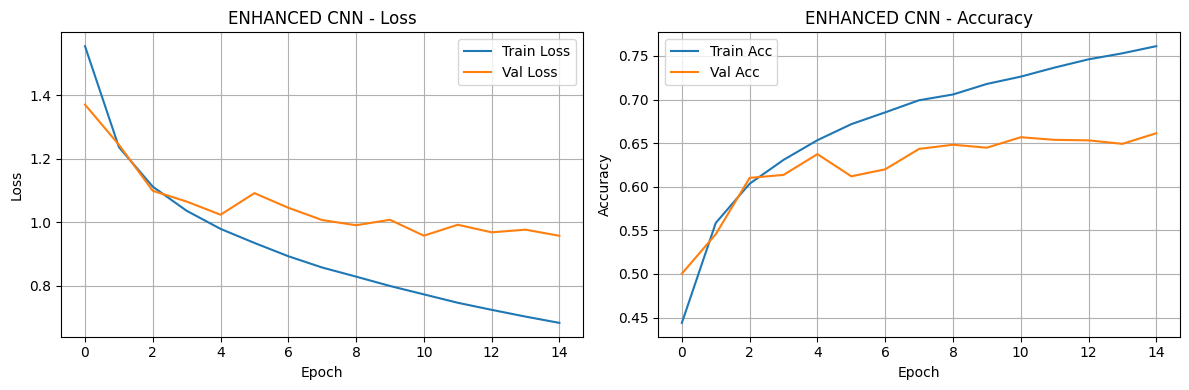


Final Test Accuracy: 0.6632
Final Test Cross-Entropy Loss: 0.9728


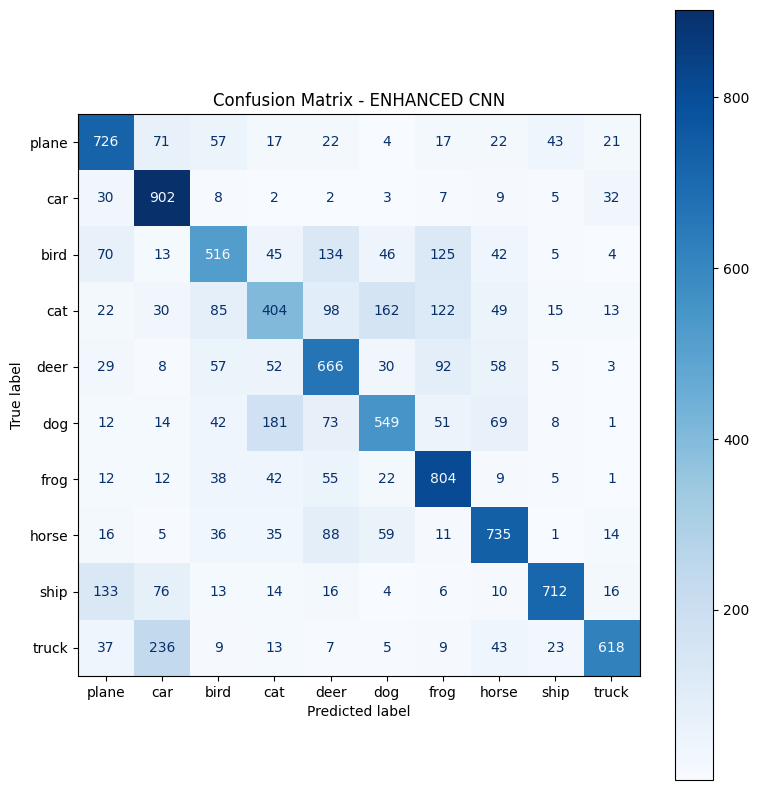


MODEL ARCHITECTURE SUMMARY
Layer                          Weight Shape                  Params
conv1.weight                   [32, 3, 3, 3]                    864
----------------------------------------------------------------------
conv1.bias                     [32]                              32
----------------------------------------------------------------------
bn1.weight                     [32]                              32
----------------------------------------------------------------------
bn1.bias                       [32]                              32
----------------------------------------------------------------------
conv2.weight                   [64, 32, 3, 3]                18,432
----------------------------------------------------------------------
conv2.bias                     [64]                              64
----------------------------------------------------------------------
bn2.weight                     [64]                              64
--

In [8]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
#from utils import plot_training_curves, evaluate_model, inspect_model_shapes, plot_confusion_matrix

def main():
    # 1. Data Preparation
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load full training set (50,000 images), hold out 5,000 for validation
    full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                  download=True, transform=transform)
    trainset, valset = random_split(full_trainset, [45000, 5000],
                                    generator=torch.Generator().manual_seed(42))

    trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    valloader = DataLoader(valset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Test set - only for final evaluation
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Training: {len(trainset)} | Validation: {len(valset)} | Test: {len(testset)}")

    # 2. Initialize Model on GPU
    model = ENHANCED_CNN2().to(device)
    print(model)

    # 3. Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 4. Train
    model.train_model(trainloader, valloader, epochs=EPOCHS,
                      criterion=criterion, optimizer=optimizer)

    # 5. Plot training and validation curves
    plot_training_curves(model, title='ENHANCED CNN')

    # 6. Evaluate on test set
    results = model.evaluate(testloader, criterion)
    print(f"\nFinal Test Accuracy: {results['accuracy']:.4f}")
    print(f"Final Test Cross-Entropy Loss: {results['loss']:.4f}")

    # 7. Confusion matrix
    plot_confusion_matrix(results['targets'], results['predictions'],
                          class_names=classes, title='Confusion Matrix - ENHANCED CNN')

    # 8. Inspect architecture shapes
    inspect_model_shapes(model)

if __name__=="__main__":
    main()

### Discussion: Comparing Baseline CNN and Enhanced CNN Architectures

In this experiment, we trained three convolutional neural network architectures on CIFAR-10: a Baseline CNN with two max-pooling layers and two fully connected layers, an Enhanced CNN that replaces the dense layers with batch normalization, a 1×1 convolution, and global average pooling (GAP), and a second Enhanced CNN variant that further removes the max-pooling layers entirely. The goal was to evaluate how replacing fully connected layers with a fully convolutional design, and how the inclusion or exclusion of max-pooling, affects classification performance and generalization.

The Baseline CNN achieved the highest test accuracy at 72.20%, but exhibited significant overfitting: training accuracy reached 94.02% by epoch 15 while validation accuracy plateaued around 72%, and the validation loss steadily increased after epoch 6 from 0.78 to 1.30. This overfitting is largely attributable to the dense layer `fc1`, which alone accounts for over 262,000 parameters (4096→64). The Enhanced CNN with max-pooling reduced the parameter count substantially by eliminating all fully connected layers, and its validation loss remained more stable (fluctuating between 0.95 and 1.03), indicating better regularization. However, it only reached approximately 67% test accuracy. The Enhanced CNN without max-pooling performed worst at 66.32% test accuracy, confirming that max-pooling plays an important role in progressively reducing spatial dimensions and expanding the effective receptive field, allowing deeper layers to capture higher-level features.

In conclusion, the Baseline CNN achieves higher raw accuracy but at the cost of severe overfitting due to its large fully connected layers, while the Enhanced CNN architectures generalize more gracefully with far fewer parameters. The key takeaway is that batch normalization and global average pooling alone are not sufficient to match the Baseline's accuracy when the convolutional layers use stride=2, which downsamples the feature maps too aggressively and discards spatial information prematurely. A well-tuned Enhanced CNN—using stride=1 convolutions with max-pooling for controlled downsampling—would likely close the accuracy gap while retaining the generalization benefits of a fully convolutional design.